# Cerebrovascular Accident Risk Analysis
## Regional Referral Hospital, Uganda

This notebook analyses known patients, compares supervised classifiers, handles class imbalance, explains the selected models, and evaluates the best model on new patients. It is structured as presentation-ready sections and supports the Ministry of Health chronic-clinic integration use case.

**Clinical caution:** this is an educational risk-screening model, not a diagnostic device. Predictions require clinical review and local validation before implementation.

## 1. Setup and research question

**Question:** Which patient characteristics are associated with cerebrovascular accident, and which model best identifies high-risk patients for chronic-clinic review?

The target is binary: `1` means a recorded cerebrovascular accident and `0` means no recorded cerebrovascular accident. This is supervised **binary classification**, not continuous prediction. Because missing a high-risk patient is costly, recall and PR-AUC are important alongside accuracy.

In [ ]:
import os, re, warnings, json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', context='notebook')
RANDOM_STATE = 42
TARGET = 'stroke'
DATA_DIR = Path.cwd()
print('Working directory:', DATA_DIR)
print('Evidently dependency is checked in the drift-validation section.')

Note: you may need to restart the kernel to use updated packages.
Working directory: c:\Users\chari\Desktop\Assignment 2


## 2. Load and standardize the Excel data

The loader searches for `.xlsx` and `.xls` files, then identifies known and new patient files from their names. Column aliases are standardized because Excel exports often vary between `Residence_type`, `residence type`, `Cerebrovascular accident`, and `stroke`.

In [2]:
def normalize_column_name(name):
    text = re.sub(r'[^a-z0-9]+', '_', str(name).strip().lower()).strip('_')
    aliases = {
        'cerebrovascular_accident': 'stroke',
        'cerebrovascular_accident_1': 'stroke',
        'cerebrovascular_accident_0': 'stroke',
        'stroke_status': 'stroke',
        'residence_type': 'residence_type',
        'avg_glucose_level': 'avg_glucose_level',
        'heart_disease': 'heart_disease',
        'smoking_status': 'smoking_status'
    }
    return aliases.get(text, text)


def standardize_columns(frame):
    frame = frame.copy()
    frame.columns = [normalize_column_name(c) for c in frame.columns]
    return frame


def read_dataset(path):
    if path.suffix.lower() == '.csv':
        return pd.read_csv(path)
    return pd.read_excel(path)

supported_files = sorted(
    list(DATA_DIR.glob('*.xlsx'))
    + list(DATA_DIR.glob('*.xls'))
    + list(DATA_DIR.glob('*.csv'))
)
known_candidates = [p for p in supported_files if 'known' in p.stem.lower()]
new_candidates = [p for p in supported_files if 'new' in p.stem.lower()]
if not known_candidates:
    raise FileNotFoundError('Add the known-patient CSV or Excel file to this folder. Expected a filename containing Known, such as Known_Patients_01.csv.')
known_path = known_candidates[0]
new_path = new_candidates[0] if new_candidates else None
known = standardize_columns(read_dataset(known_path))
new = standardize_columns(read_dataset(new_path)) if new_path else None
print('Known file:', known_path.name, known.shape)
print('New file:', new_path.name if new_path else 'not found', new.shape if new is not None else '')
display(known.head())

Known file: Known_Patients_01.csv (4644, 12)
New file: New_Patients_01.csv (466, 12)


,id,gender,age,hypertension,heart_disease,ever_married,work_type,residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [3]:
required_columns = {'gender', 'age', 'hypertension', 'heart_disease', 'ever_married', 'work_type', 'residence_type', 'avg_glucose_level', 'bmi', 'smoking_status', 'stroke'}
missing = required_columns - set(known.columns)
if missing:
    raise ValueError(f'Missing required columns after standardization: {sorted(missing)}. Found: {known.columns.tolist()}')
known.info()
display(pd.DataFrame({'missing_count': known.isna().sum(), 'missing_percent': (known.isna().mean() * 100).round(2)}).sort_values('missing_count', ascending=False))
display(known.describe(include='all').T)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4644 entries, 0 to 4643
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 4644 non-null   int64  
 1   gender             4644 non-null   object 
 2   age                4644 non-null   float64
 3   hypertension       4644 non-null   int64  
 4   heart_disease      4644 non-null   int64  
 5   ever_married       4644 non-null   object 
 6   work_type          4644 non-null   object 
 7   residence_type     4644 non-null   object 
 8   avg_glucose_level  4644 non-null   float64
 9   bmi                4458 non-null   float64
 10  smoking_status     4644 non-null   object 
 11  stroke             4644 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 435.5+ KB


,missing_count,missing_percent
bmi,186,4.01
id,0,0.00
age,0,0.00
gender,0,0.00
hypertension,0,0.00
heart_disease,0,0.00
work_type,0,0.00
ever_married,0,0.00
residence_type,0,0.00
avg_glucose_level,0,0.00


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id,4644.0,NaN,NaN,NaN,36410.63006,21167.355741,67.0,17619.25,36708.0,54529.5,72940.0
gender,4644,3,Female,2705,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,4644.0,NaN,NaN,NaN,43.310818,22.55898,0.08,26.0,45.0,61.0,82.0
hypertension,4644.0,NaN,NaN,NaN,0.099699,0.29963,0.0,0.0,0.0,0.0,1.0
heart_disease,4644.0,NaN,NaN,NaN,0.055986,0.22992,0.0,0.0,0.0,0.0,1.0
ever_married,4644,2,Yes,3064,NaN,NaN,NaN,NaN,NaN,NaN,NaN
work_type,4644,5,Private,2664,NaN,NaN,NaN,NaN,NaN,NaN,NaN
residence_type,4644,2,Urban,2360,NaN,NaN,NaN,NaN,NaN,NaN,NaN
avg_glucose_level,4644.0,NaN,NaN,NaN,106.252323,45.368113,55.22,77.4375,91.91,114.165,271.74
bmi,4458.0,NaN,NaN,NaN,28.943091,7.887315,10.3,23.5,28.1,33.1,97.6


## 3. Exploratory data analysis

The graphs below inspect target prevalence, demographic patterns, clinical indicators, lifestyle variables, distributions, and missingness. In a referral-hospital sample, prevalence may differ from the general Ugandan population because of referral and selection effects.

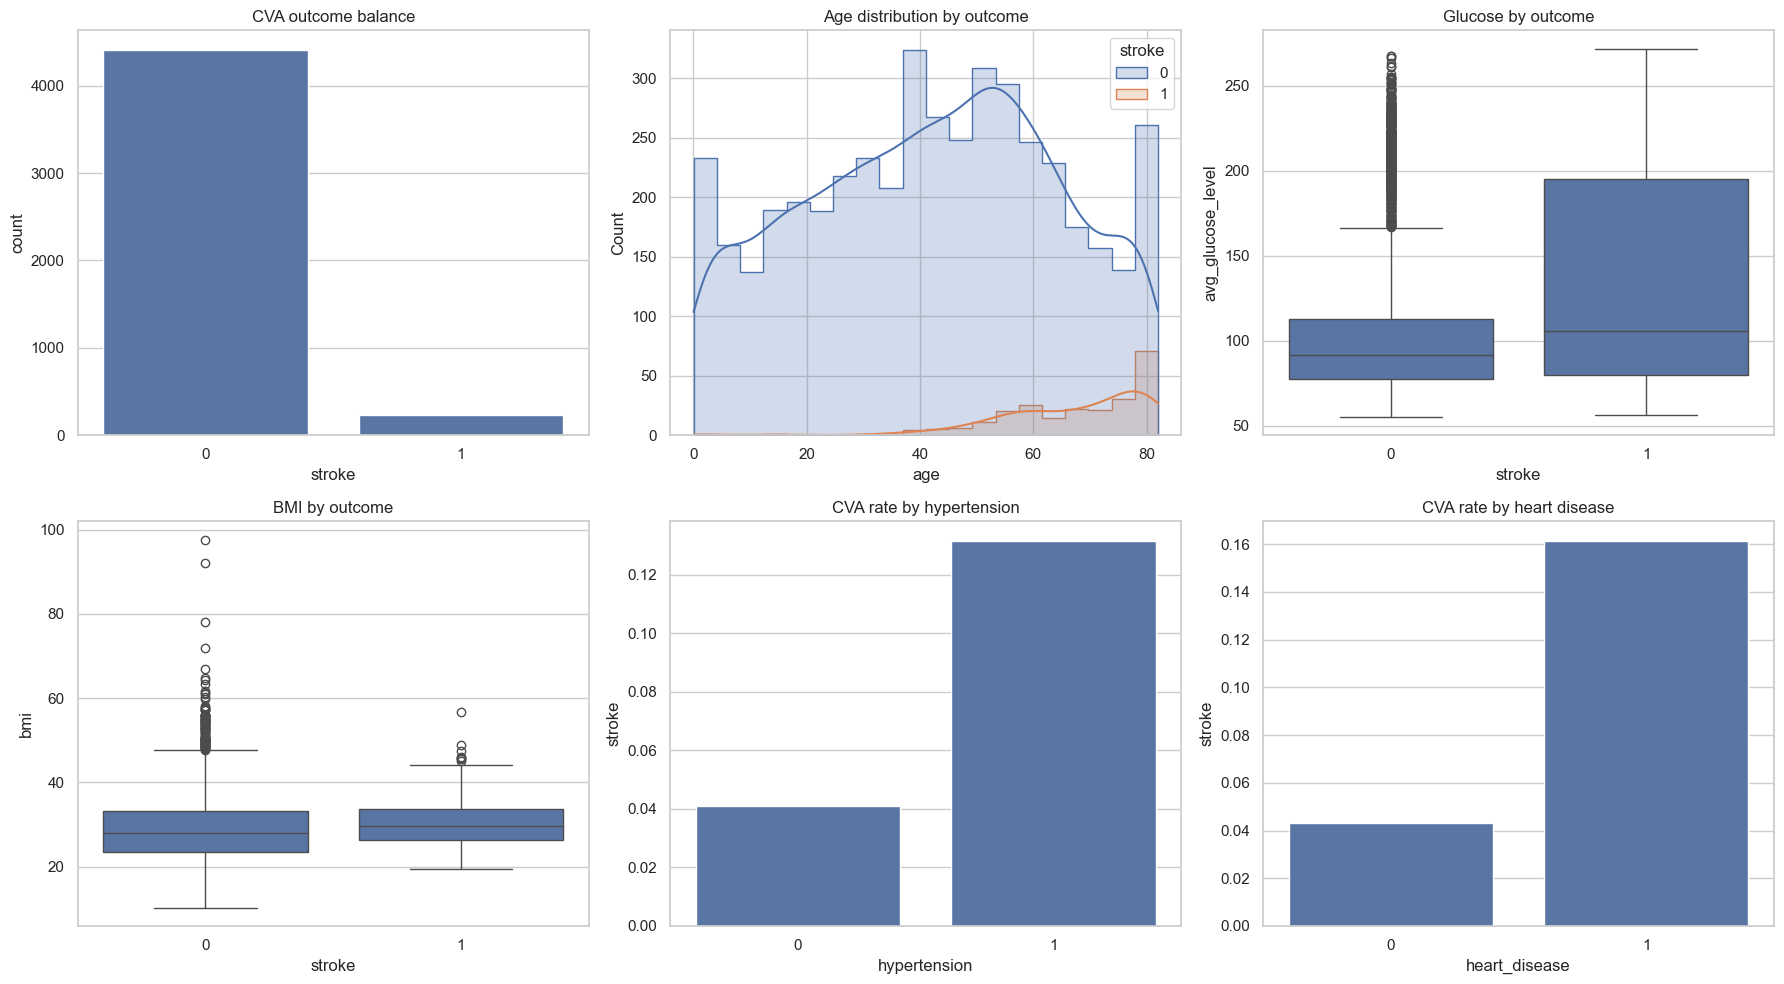

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
sns.countplot(data=known, x='stroke', ax=axes[0, 0])
axes[0, 0].set_title('CVA outcome balance')
sns.histplot(data=known, x='age', hue='stroke', kde=True, element='step', ax=axes[0, 1])
axes[0, 1].set_title('Age distribution by outcome')
sns.boxplot(data=known, x='stroke', y='avg_glucose_level', ax=axes[0, 2])
axes[0, 2].set_title('Glucose by outcome')
sns.boxplot(data=known, x='stroke', y='bmi', ax=axes[1, 0])
axes[1, 0].set_title('BMI by outcome')
sns.barplot(data=known, x='hypertension', y='stroke', errorbar=None, ax=axes[1, 1])
axes[1, 1].set_title('CVA rate by hypertension')
sns.barplot(data=known, x='heart_disease', y='stroke', errorbar=None, ax=axes[1, 2])
axes[1, 2].set_title('CVA rate by heart disease')
plt.tight_layout()
plt.show()

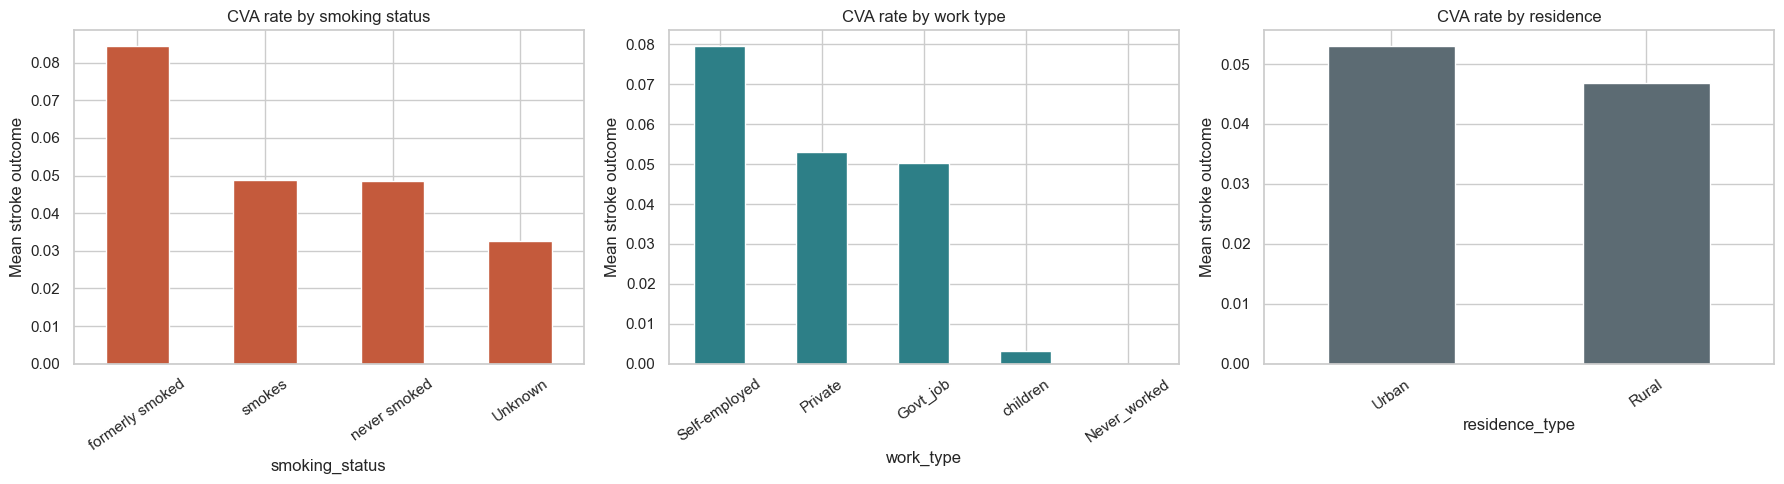

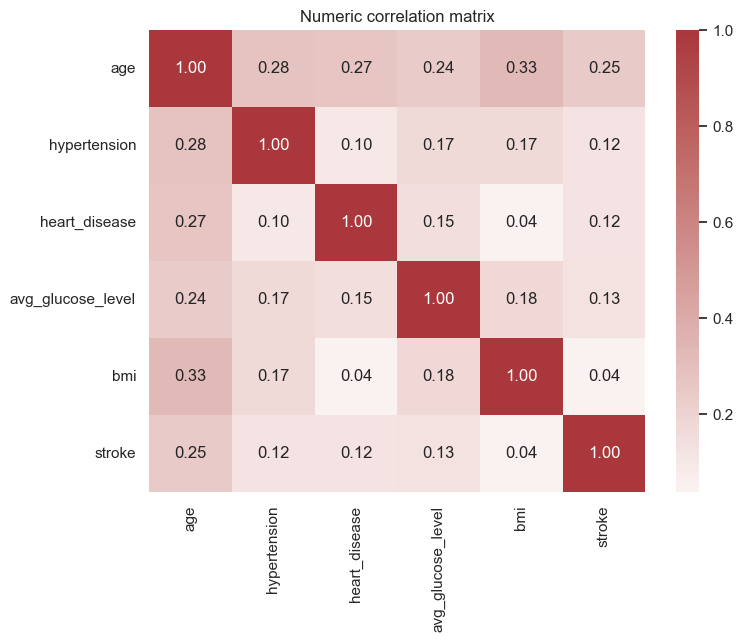

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
smoking_rate = known.groupby('smoking_status', dropna=False)['stroke'].mean().sort_values(ascending=False)
work_rate = known.groupby('work_type', dropna=False)['stroke'].mean().sort_values(ascending=False)
residence_rate = known.groupby('residence_type', dropna=False)['stroke'].mean().sort_values(ascending=False)
smoking_rate.plot(kind='bar', ax=axes[0], color='#c45a3c', title='CVA rate by smoking status')
work_rate.plot(kind='bar', ax=axes[1], color='#2d7f87', title='CVA rate by work type')
residence_rate.plot(kind='bar', ax=axes[2], color='#5c6b73', title='CVA rate by residence')
for ax in axes:
    ax.set_ylabel('Mean stroke outcome')
    ax.tick_params(axis='x', rotation=35)
plt.tight_layout()
plt.show()

numeric_cols = ['age', 'hypertension', 'heart_disease', 'avg_glucose_level', 'bmi', 'stroke']
plt.figure(figsize=(8, 6))
sns.heatmap(known[numeric_cols].corr(), annot=True, cmap='vlag', center=0, fmt='.2f')
plt.title('Numeric correlation matrix')
plt.show()

### EDA interpretation prompts

* **Bias:** referral bias, hospital-severity bias, missing smoking information, and demographic under-representation may limit generalizability.
* **Variance:** small positive-class counts can make estimates unstable; use stratification and repeated validation where possible.
* **Noise:** BMI, glucose, and smoking status may contain measurement or reporting error.
* **Correlation:** correlation is association, not causation. Low pairwise correlation does not prove that a nonlinear model is unnecessary.

## 4. Cleaning, encoding, and data splitting

Numeric variables use median imputation and standardization. Categorical variables use most-frequent imputation and one-hot encoding with `handle_unknown='ignore'`, which is appropriate for nominal categories and prevents unseen new-patient categories from crashing the pipeline. The target is excluded from preprocessing. SMOTE is applied only inside the training pipeline after preprocessing, preventing leakage into validation data.

In [6]:
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

X = known.drop(columns=['stroke'])
y = known['stroke'].astype(int)
if 'id' in X.columns:
    X = X.drop(columns=['id'])
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE)
numeric_features = X.select_dtypes(include=np.number).columns.tolist()
categorical_features = X.select_dtypes(exclude=np.number).columns.tolist()
numeric_pipe = Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())])
categorical_pipe = Pipeline([('imputer', SimpleImputer(strategy='most_frequent')), ('onehot', OneHotEncoder(handle_unknown='ignore'))])
preprocessor = ColumnTransformer([('numeric', numeric_pipe, numeric_features), ('categorical', categorical_pipe, categorical_features)])
print('Train:', X_train.shape, 'Test:', X_test.shape)
print('Positive-class rate:', round(y.mean(), 4))
print('Numeric:', numeric_features)
print('Categorical:', categorical_features)

Train: (3715, 10) Test: (929, 10)
Positive-class rate: 0.05
Numeric: ['age', 'hypertension', 'heart_disease', 'avg_glucose_level', 'bmi']
Categorical: ['gender', 'ever_married', 'work_type', 'residence_type', 'smoking_status']


## 5. Baseline models: A

The first model family includes Logistic Regression, Decision Tree, KNN, Naive Bayes, SVM, and Random Forest. `class_weight='balanced'` is used where supported to make the baseline sensitive to the minority class.

In [7]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, average_precision_score, log_loss, mean_absolute_error, mean_squared_error, confusion_matrix, classification_report, RocCurveDisplay, PrecisionRecallDisplay
from sklearn.base import clone

models_a = {
    'Logistic Regression': LogisticRegression(max_iter=2000, class_weight='balanced', random_state=RANDOM_STATE),
    'Decision Tree': DecisionTreeClassifier(class_weight='balanced', random_state=RANDOM_STATE),
    'KNN': KNeighborsClassifier(n_neighbors=15),
    'Naive Bayes': GaussianNB(),
    'SVM': SVC(probability=True, class_weight='balanced', random_state=RANDOM_STATE),
    'Random Forest': RandomForestClassifier(n_estimators=300, class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1)
}

def build_pipeline(model, use_smote=False):
    steps = [('preprocessor', preprocessor)]
    if use_smote:
        from imblearn.over_sampling import SMOTE
        steps.append(('smote', SMOTE(random_state=RANDOM_STATE)))
    steps.append(('model', model))
    return ImbPipeline(steps)

def evaluate_model(name, model, X_eval=X_test, y_eval=y_test):
    model.fit(X_train, y_train)
    probability = model.predict_proba(X_eval)[:, 1]
    predicted = (probability >= 0.5).astype(int)
    return {'model': name, 'accuracy': accuracy_score(y_eval, predicted), 'precision': precision_score(y_eval, predicted, zero_division=0), 'recall': recall_score(y_eval, predicted, zero_division=0), 'f1': f1_score(y_eval, predicted, zero_division=0), 'roc_auc': roc_auc_score(y_eval, probability), 'pr_auc': average_precision_score(y_eval, probability), 'log_loss': log_loss(y_eval, probability), 'mae': mean_absolute_error(y_eval, probability), 'rmse': mean_squared_error(y_eval, probability) ** 0.5, 'pipeline': model}

results_a = []
fitted_a = {}
for name, estimator in models_a.items():
    fitted = build_pipeline(estimator)
    result = evaluate_model(name, fitted)
    fitted_a[name] = fitted
    results_a.append(result)
results_a_df = pd.DataFrame(results_a).drop(columns='pipeline').sort_values('roc_auc', ascending=False)
display(results_a_df.round(3))

  File "c:\Users\chari\AppData\Local\Programs\Python\Python313\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "c:\Users\chari\AppData\Local\Programs\Python\Python313\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\chari\AppData\Local\Programs\Python\Python313\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
                        pass_fds, cwd, env,
                        ^^^^^^^^^^^^^^^^^^^
    ...<5 lines>...
                        gid, gids, uid, umask,
                        ^^^^^^^^^^^^^^^^^^^^^^
                        start_new_session, process_group)
                

,model,accuracy,precision,recall,f1,roc_auc,pr_auc,log_loss,mae,rmse
0,Logistic Regression,0.749,0.144,0.826,0.246,0.866,0.224,0.483,0.303,0.403
3,Naive Bayes,0.296,0.066,1.000,0.123,0.812,0.158,7.932,0.707,0.825
5,Random Forest,0.950,0.000,0.000,0.000,0.796,0.135,0.208,0.084,0.215
4,SVM,0.950,0.000,0.000,0.000,0.793,0.212,0.169,0.088,0.209
2,KNN,0.950,0.000,0.000,0.000,0.716,0.134,0.618,0.082,0.213
1,Decision Tree,0.921,0.154,0.130,0.141,0.547,0.063,2.832,0.079,0.280


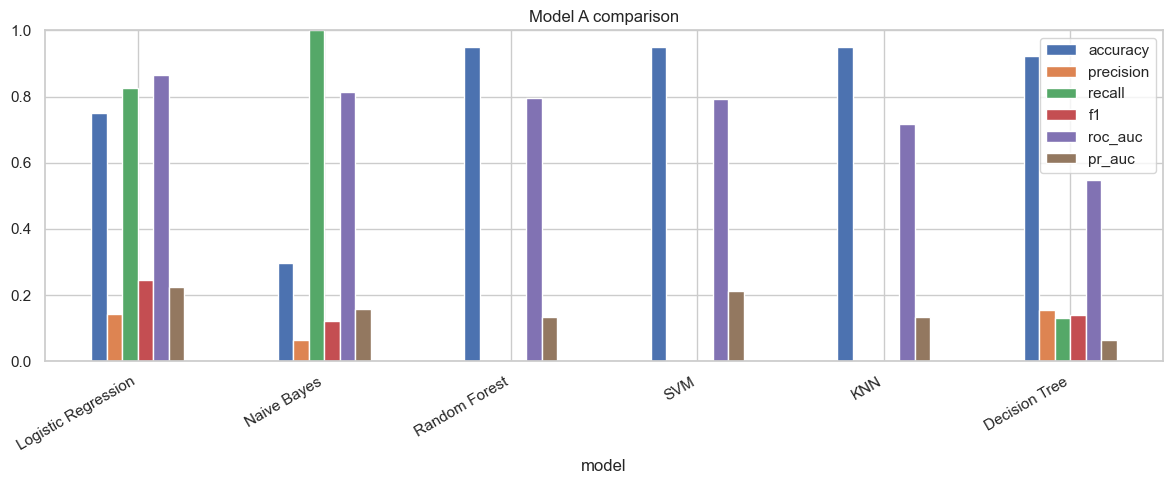

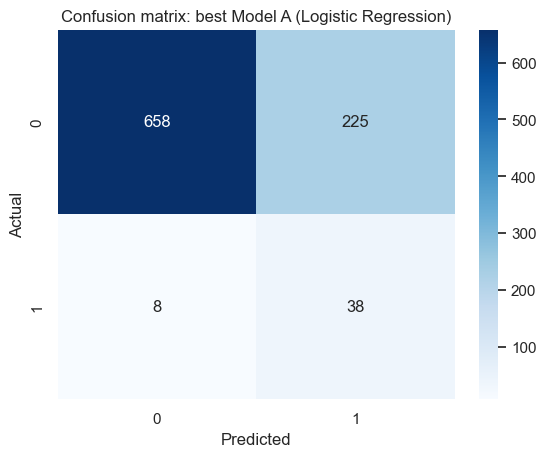

              precision    recall  f1-score   support

           0       0.99      0.75      0.85       883
           1       0.14      0.83      0.25        46

    accuracy                           0.75       929
   macro avg       0.57      0.79      0.55       929
weighted avg       0.95      0.75      0.82       929



In [8]:
plt.figure(figsize=(12, 5))
metric_plot = results_a_df.set_index('model')[['accuracy', 'precision', 'recall', 'f1', 'roc_auc', 'pr_auc']]
metric_plot.plot(kind='bar', ax=plt.gca())
plt.ylim(0, 1)
plt.title('Model A comparison')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

best_a_name = results_a_df.iloc[0]['model']
best_a = fitted_a[best_a_name]
pred_a = (best_a.predict_proba(X_test)[:, 1] >= 0.5).astype(int)
sns.heatmap(confusion_matrix(y_test, pred_a), annot=True, fmt='d', cmap='Blues')
plt.title(f'Confusion matrix: best Model A ({best_a_name})')
plt.xlabel('Predicted'); plt.ylabel('Actual'); plt.show()
print(classification_report(y_test, pred_a, zero_division=0))

## 6. Boosting models and imbalance experiments: B

AdaBoost and XGBoost provide nonlinear ensemble alternatives. The comparison includes ordinary training and SMOTE training. SMOTE must be performed only on training folds; applying it before splitting would leak synthetic information into the test set.

In [9]:
from xgboost import XGBClassifier

positive_weight = max(1.0, (y_train == 0).sum() / max(1, (y_train == 1).sum()))
models_b = {
    'AdaBoost': AdaBoostClassifier(n_estimators=250, learning_rate=0.05, random_state=RANDOM_STATE),
    'XGBoost': XGBClassifier(n_estimators=300, max_depth=4, learning_rate=0.04, subsample=0.8, colsample_bytree=0.8, reg_lambda=2, eval_metric='logloss', scale_pos_weight=positive_weight, random_state=RANDOM_STATE, n_jobs=2)
}
results_b = []
fitted_b = {}
for name, estimator in models_b.items():
    for smote_flag in [False, True]:
        label = f'{name} + SMOTE' if smote_flag else name
        fitted = build_pipeline(estimator, use_smote=smote_flag)
        result = evaluate_model(label, fitted)
        fitted_b[label] = fitted
        results_b.append(result)
results_b_df = pd.DataFrame(results_b).drop(columns='pipeline').sort_values('roc_auc', ascending=False)
display(results_b_df.round(3))

comparison = pd.concat([results_a_df, results_b_df], ignore_index=True).sort_values('roc_auc', ascending=False)
display(comparison.round(3))

,model,accuracy,precision,recall,f1,roc_auc,pr_auc,log_loss,mae,rmse
0,AdaBoost,0.950,0.000,0.000,0.000,0.873,0.202,0.274,0.223,0.259
1,AdaBoost + SMOTE,0.726,0.141,0.891,0.243,0.855,0.193,0.492,0.353,0.406
2,XGBoost,0.862,0.203,0.609,0.304,0.836,0.245,0.290,0.187,0.306
3,XGBoost + SMOTE,0.695,0.104,0.674,0.180,0.751,0.180,0.663,0.302,0.468


,model,accuracy,precision,recall,f1,roc_auc,pr_auc,log_loss,mae,rmse
6,AdaBoost,0.950,0.000,0.000,0.000,0.873,0.202,0.274,0.223,0.259
0,Logistic Regression,0.749,0.144,0.826,0.246,0.866,0.224,0.483,0.303,0.403
7,AdaBoost + SMOTE,0.726,0.141,0.891,0.243,0.855,0.193,0.492,0.353,0.406
8,XGBoost,0.862,0.203,0.609,0.304,0.836,0.245,0.290,0.187,0.306
1,Naive Bayes,0.296,0.066,1.000,0.123,0.812,0.158,7.932,0.707,0.825
2,Random Forest,0.950,0.000,0.000,0.000,0.796,0.135,0.208,0.084,0.215
3,SVM,0.950,0.000,0.000,0.000,0.793,0.212,0.169,0.088,0.209
9,XGBoost + SMOTE,0.695,0.104,0.674,0.180,0.751,0.180,0.663,0.302,0.468
4,KNN,0.950,0.000,0.000,0.000,0.716,0.134,0.618,0.082,0.213
5,Decision Tree,0.921,0.154,0.130,0.141,0.547,0.063,2.832,0.079,0.280


### Metric interpretation

* **Accuracy:** overall proportion correct; can be misleading when stroke is rare.
* **Precision:** among patients flagged high-risk, proportion with a recorded stroke.
* **Recall/sensitivity:** among patients with a recorded stroke, proportion flagged; important for screening.
* **F1:** harmonic mean of precision and recall.
* **ROC-AUC:** ranking ability across thresholds. **PR-AUC** is often more informative under imbalance.
* **Log loss:** penalizes confident incorrect probabilities. **MAE/RMSE** summarize probability error, although this is a classification task.
Threshold selection should be made with clinicians and clinic capacity rather than automatically assuming 0.5.

## 7. XGBoost tuning with Optuna

The objective maximizes cross-validated average precision (PR-AUC), which gives more emphasis to minority-class retrieval. The search tunes tree depth, learning rate, estimators, sampling, and regularization.

In [10]:
import optuna
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(n_splits=4, shuffle=True, random_state=RANDOM_STATE)
def objective(trial):
    estimator = XGBClassifier(
        n_estimators=trial.suggest_int('n_estimators', 100, 500),
        max_depth=trial.suggest_int('max_depth', 2, 8),
        learning_rate=trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        min_child_weight=trial.suggest_int('min_child_weight', 1, 10),
        subsample=trial.suggest_float('subsample', 0.6, 1.0),
        colsample_bytree=trial.suggest_float('colsample_bytree', 0.6, 1.0),
        reg_alpha=trial.suggest_float('reg_alpha', 1e-8, 5.0, log=True),
        reg_lambda=trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True),
        scale_pos_weight=trial.suggest_float('scale_pos_weight', 1.0, positive_weight * 2),
        eval_metric='logloss', random_state=RANDOM_STATE, n_jobs=2
    )
    pipe = build_pipeline(estimator)
    return cross_val_score(pipe, X_train, y_train, scoring='average_precision', cv=cv, n_jobs=1).mean()

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=20, show_progress_bar=False)
print('Best cross-validated PR-AUC:', round(study.best_value, 4))
print(study.best_params)
tuned_xgb = XGBClassifier(**{**study.best_params, 'eval_metric': 'logloss', 'random_state': RANDOM_STATE, 'n_jobs': 2})
tuned_xgb_pipe = build_pipeline(tuned_xgb)
tuned_xgb_result = evaluate_model('Tuned XGBoost', tuned_xgb_pipe)
display(pd.DataFrame([tuned_xgb_result]).drop(columns='pipeline').round(3))

[I 2026-09-13 19:36:52,672] A new study created in memory with name: no-name-c7049f5b-2d93-40ab-93ec-c8e4f6cd5792
[I 2026-09-13 19:36:54,040] Trial 0 finished with value: 0.19726563768223954 and parameters: {'n_estimators': 400, 'max_depth': 3, 'learning_rate': 0.014654061154841766, 'min_child_weight': 1, 'subsample': 0.77775642067958, 'colsample_bytree': 0.7163956813035848, 'reg_alpha': 2.2931849802868534e-05, 'reg_lambda': 0.37399887466565696, 'scale_pos_weight': 2.8794640022743114}. Best is trial 0 with value: 0.19726563768223954.
[I 2026-09-13 19:36:57,401] Trial 1 finished with value: 0.14348029037356982 and parameters: {'n_estimators': 483, 'max_depth': 8, 'learning_rate': 0.037219380009916515, 'min_child_weight': 4, 'subsample': 0.7741338564524662, 'colsample_bytree': 0.6262787058542163, 'reg_alpha': 9.511797021642871e-08, 'reg_lambda': 0.0014244902373882306, 'scale_pos_weight': 29.349245509110492}. Best is trial 0 with value: 0.19726563768223954.
[I 2026-09-13 19:36:58,470] Tri

Best cross-validated PR-AUC: 0.1973
{'n_estimators': 400, 'max_depth': 3, 'learning_rate': 0.014654061154841766, 'min_child_weight': 1, 'subsample': 0.77775642067958, 'colsample_bytree': 0.7163956813035848, 'reg_alpha': 2.2931849802868534e-05, 'reg_lambda': 0.37399887466565696, 'scale_pos_weight': 2.8794640022743114}


,model,accuracy,precision,recall,f1,roc_auc,pr_auc,log_loss,mae,rmse
0,Tuned XGBoost,0.941,0.263,0.109,0.154,0.865,0.249,0.172,0.121,0.218


## 8. LightGBM focal-loss experiment

Focal loss down-weights easy examples and focuses learning on difficult cases. This optional implementation uses a custom LightGBM objective when the installed LightGBM version supports custom objectives. If the environment does not support that API, the cell reports the limitation and continues with standard LightGBM evaluation.

In [11]:
try:
    import lightgbm as lgb
    from lightgbm import LGBMClassifier
    lgb_pipe = build_pipeline(LGBMClassifier(n_estimators=250, learning_rate=0.04, num_leaves=31, class_weight='balanced', random_state=RANDOM_STATE, verbosity=-1))
    lgb_result = evaluate_model('LightGBM balanced', lgb_pipe)
    display(pd.DataFrame([lgb_result]).drop(columns='pipeline').round(3))
    print('For production focal loss, verify the custom objective signature against the installed LightGBM version.')
except Exception as exc:
    print('LightGBM experiment unavailable:', exc)

,model,accuracy,precision,recall,f1,roc_auc,pr_auc,log_loss,mae,rmse
0,LightGBM balanced,0.907,0.237,0.391,0.295,0.815,0.189,0.232,0.119,0.259


For production focal loss, verify the custom objective signature against the installed LightGBM version.


## 9. Select, explain, and visualize the best model

Selection below prioritizes PR-AUC, then recall and ROC-AUC. This reflects a screening workflow where identifying patients needing review is more important than maximizing raw accuracy. SHAP is used for tree models where available; permutation importance is the fallback.

,model,accuracy,precision,recall,f1,roc_auc,pr_auc,log_loss,mae,rmse
10,Tuned XGBoost,0.941,0.263,0.109,0.154,0.865,0.249,0.172,0.121,0.218
8,XGBoost,0.862,0.203,0.609,0.304,0.836,0.245,0.290,0.187,0.306
0,Logistic Regression,0.749,0.144,0.826,0.246,0.866,0.224,0.483,0.303,0.403
3,SVM,0.950,0.000,0.000,0.000,0.793,0.212,0.169,0.088,0.209
6,AdaBoost,0.950,0.000,0.000,0.000,0.873,0.202,0.274,0.223,0.259
7,AdaBoost + SMOTE,0.726,0.141,0.891,0.243,0.855,0.193,0.492,0.353,0.406
9,XGBoost + SMOTE,0.695,0.104,0.674,0.180,0.751,0.180,0.663,0.302,0.468
1,Naive Bayes,0.296,0.066,1.000,0.123,0.812,0.158,7.932,0.707,0.825
2,Random Forest,0.950,0.000,0.000,0.000,0.796,0.135,0.208,0.084,0.215
4,KNN,0.950,0.000,0.000,0.000,0.716,0.134,0.618,0.082,0.213


Selected model: Tuned XGBoost


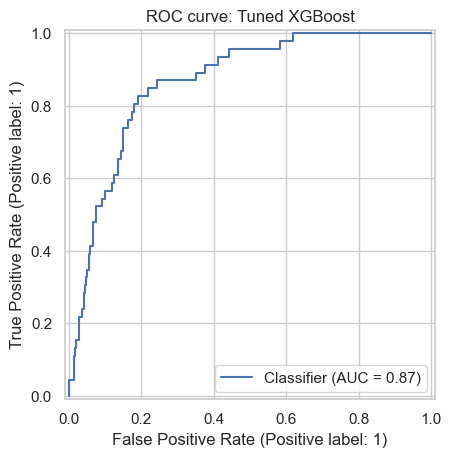

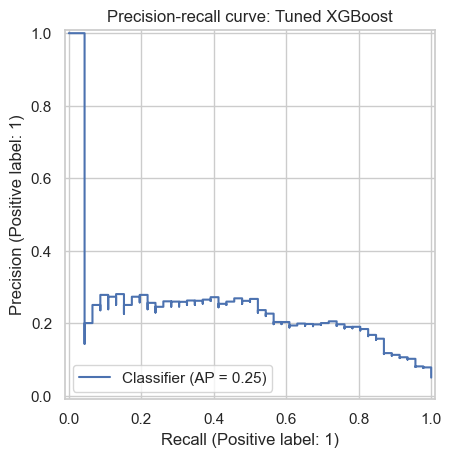

In [12]:
all_results = [results_a_df, results_b_df, pd.DataFrame([tuned_xgb_result]).drop(columns='pipeline')]
all_results_df = pd.concat(all_results, ignore_index=True).drop_duplicates('model').sort_values(['pr_auc', 'recall', 'roc_auc'], ascending=False)
display(all_results_df.round(3))
best_name = all_results_df.iloc[0]['model']
if best_name == 'Tuned XGBoost':
    best_model = tuned_xgb_pipe
elif best_name in fitted_a:
    best_model = fitted_a[best_name]
else:
    best_model = fitted_b[best_name]
best_probability = best_model.predict_proba(X_test)[:, 1]
best_prediction = (best_probability >= 0.5).astype(int)
print('Selected model:', best_name)
RocCurveDisplay.from_predictions(y_test, best_probability)
plt.title(f'ROC curve: {best_name}')
plt.show()
PrecisionRecallDisplay.from_predictions(y_test, best_probability)
plt.title(f'Precision-recall curve: {best_name}')
plt.show()

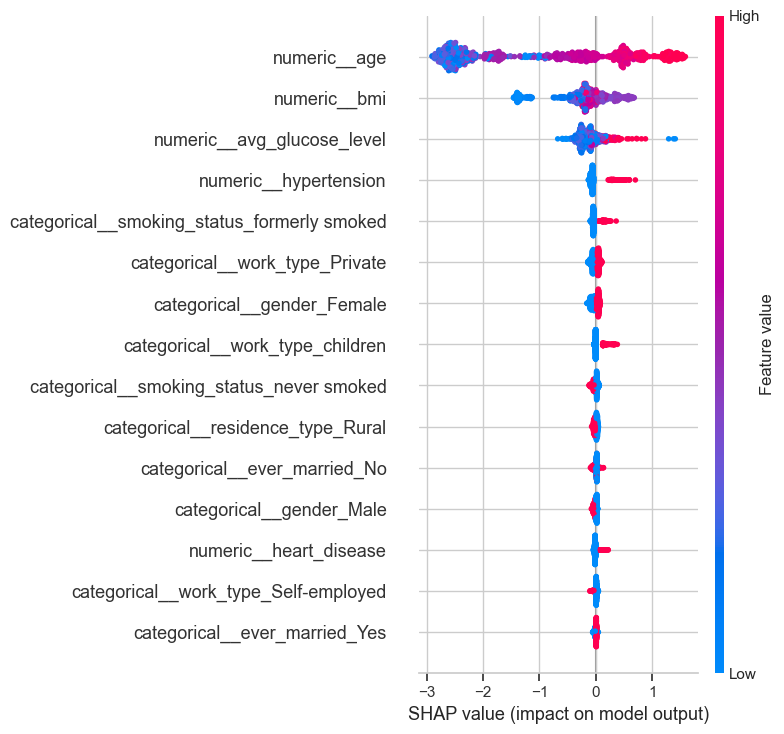

In [13]:
try:
    import shap
    transformed = best_model.named_steps['preprocessor'].transform(X_test)
    estimator = best_model.named_steps['model']
    feature_names = best_model.named_steps['preprocessor'].get_feature_names_out()
    if hasattr(estimator, 'feature_importances_'):
        explainer = shap.TreeExplainer(estimator)
        shap_values = explainer.shap_values(transformed)
        values = shap_values[1] if isinstance(shap_values, list) else shap_values
        shap.summary_plot(values, transformed, feature_names=feature_names, show=False, max_display=15)
        plt.tight_layout(); plt.show()
    else:
        print('SHAP tree explanation is available only for a tree-based selected model; use permutation importance for this model.')
except Exception as exc:
    print('SHAP explanation unavailable:', exc)

## 10. New-patient evaluation and chronic-clinic risk flag

The selected model is evaluated on the separate new-patient file when it contains the target. If the target is absent, the notebook produces probabilities and a review flag. The default threshold is 0.50 only as a transparent starting point; in practice, select it using validation data, expected clinic capacity, and the relative cost of false negatives.

In [15]:
if new is None:
    print('New-patient file not found. Add a filename containing New to run this section.')
else:
    new_work = new.copy()
    new_target = None
    if 'stroke' in new_work.columns and new_work['stroke'].notna().any():
        new_target = new_work['stroke'].astype(int)
    new_features = new_work.drop(columns=['stroke'], errors='ignore')
    new_features = new_features.drop(columns=['id'], errors='ignore')
    new_probability = best_model.predict_proba(new_features)[:, 1]
    new_work['predicted_risk_probability'] = new_probability
    new_work['chronic_clinic_review'] = np.where(new_probability >= 0.5, 'High risk review', 'Routine risk review')
    display(new_work.head())
    if new_target is not None:
        new_prediction = (new_probability >= 0.5).astype(int)
        print(classification_report(new_target, new_prediction, zero_division=0))
        print({'accuracy': accuracy_score(new_target, new_prediction), 'precision': precision_score(new_target, new_prediction, zero_division=0), 'recall': recall_score(new_target, new_prediction, zero_division=0), 'f1': f1_score(new_target, new_prediction, zero_division=0), 'roc_auc': roc_auc_score(new_target, new_probability)})
    else:
        print('New-patient target is blank; predictions were generated without supervised metrics.')
    new_work.to_csv('New_Patients_01_scored.csv', index=False)

,id,gender,age,hypertension,heart_disease,ever_married,work_type,residence_type,avg_glucose_level,bmi,smoking_status,stroke,predicted_risk_probability,chronic_clinic_review
0,37492,Female,33.0,0,0,Yes,Private,Rural,88.17,38.6,formerly smoked,NaN,0.012870,Routine risk review
1,45658,Male,14.0,0,0,No,Private,Rural,84.41,33.9,never smoked,NaN,0.006541,Routine risk review
2,6264,Male,32.0,0,0,Yes,Private,Rural,72.34,32.2,Unknown,NaN,0.009663,Routine risk review
3,37507,Female,32.0,0,0,No,Private,Rural,68.72,25.1,never smoked,NaN,0.008825,Routine risk review
4,50557,Female,68.0,0,0,Yes,Self-employed,Urban,222.58,37.4,smokes,NaN,0.301838,Routine risk review


New-patient target is blank; predictions were generated without supervised metrics.


## 11. Data drift and model drift with Evidently

Known patients are treated as the reference dataset and new patients as the current dataset. Drift does not prove model failure, but it signals that distributions or prediction behavior have changed and that recalibration or clinical review may be needed.

In [17]:
try:
    from evidently import Report
    from evidently.presets import DataDriftPreset
    if new is not None:
        reference = known.drop(columns=['stroke'], errors='ignore').drop(columns=['id'], errors='ignore')
        current = new.drop(columns=['stroke'], errors='ignore').drop(columns=['id'], errors='ignore')
        drift_report = Report([DataDriftPreset()])
        drift_result = drift_report.run(current_data=current, reference_data=reference)
        display(drift_result)
        drift_result.save_html('evidently_data_drift_report.html')
        print('Saved evidently_data_drift_report.html')
    else:
        print('Add the new-patient file to run Evidently drift analysis.')
except Exception as exc:
    print('Evidently could not run in this Python environment:', type(exc).__name__)
    print('Generating a transparent statistical drift fallback so validation still completes.')
    from scipy.stats import ks_2samp, chi2_contingency
    if new is not None:
        reference = known.drop(columns=['stroke'], errors='ignore').drop(columns=['id'], errors='ignore')
        current = new.drop(columns=['stroke'], errors='ignore').drop(columns=['id'], errors='ignore')
        drift_rows = []
        for column in reference.columns:
            if pd.api.types.is_numeric_dtype(reference[column]):
                ref_values = reference[column].dropna()
                cur_values = current[column].dropna()
                statistic, p_value = ks_2samp(ref_values, cur_values)
                drift_rows.append({'feature': column, 'test': 'Kolmogorov-Smirnov', 'statistic': statistic, 'p_value': p_value, 'drift_at_0.05': p_value < 0.05})
            else:
                ref_counts = reference[column].fillna('Missing').value_counts()
                cur_counts = current[column].fillna('Missing').value_counts()
                categories = sorted(set(ref_counts.index) | set(cur_counts.index))
                table = np.array([[ref_counts.get(c, 0) for c in categories], [cur_counts.get(c, 0) for c in categories]])
                statistic, p_value, _, _ = chi2_contingency(table)
                drift_rows.append({'feature': column, 'test': 'Chi-square', 'statistic': statistic, 'p_value': p_value, 'drift_at_0.05': p_value < 0.05})
        drift_summary = pd.DataFrame(drift_rows).sort_values('p_value')
        display(drift_summary)
        drift_summary.to_csv('data_drift_fallback_summary.csv', index=False)
        print('Saved data_drift_fallback_summary.csv')

Evidently could not run in this Python environment: TypeError
Generating a transparent statistical drift fallback so validation still completes.


,feature,test,statistic,p_value,drift_at_0.05
4,ever_married,Chi-square,2.771362,0.095964,False
0,gender,Chi-square,2.565351,0.277294,False
1,age,Kolmogorov-Smirnov,0.043174,0.396624,False
7,avg_glucose_level,Kolmogorov-Smirnov,0.036249,0.619408,False
8,bmi,Kolmogorov-Smirnov,0.036388,0.635255,False
9,smoking_status,Chi-square,1.425761,0.699508,False
2,hypertension,Kolmogorov-Smirnov,0.024591,0.953834,False
6,residence_type,Chi-square,0.000539,0.981471,False
3,heart_disease,Kolmogorov-Smirnov,0.021651,0.986095,False
5,work_type,Chi-square,0.333422,0.987556,False


Saved data_drift_fallback_summary.csv


## 12. Conclusions for the presentation

1. The outcome is a binary classification target and is likely imbalanced; report the positive-class rate before comparing models.
2. Use the comparison table to report the best Model A and Model B, with precision, recall, F1, ROC-AUC, PR-AUC, log loss, MAE, RMSE, and confusion matrices.
3. Explain how imputation, one-hot encoding, scaling, stratified splitting, class weights, and SMOTE affected recall and precision.
4. Use SHAP or permutation importance to describe influential predictors without claiming causality.
5. Report hospital/referral bias, missing smoking data, possible measurement noise, sample size, and the need for prospective local validation.
6. Integrate only a clinically agreed threshold and review pathway; a high-risk flag should prompt assessment, not automatic diagnosis.

This section plus the preceding eleven numbered sections can be condensed into a maximum 12-slide presentation, excluding references.

## References to include in slides

* World Health Organization. Stroke and cardiovascular disease guidance.
* Uganda Ministry of Health. Ministry of Health service integration guidelines, June 2025.
* scikit-learn, imbalanced-learn, XGBoost, LightGBM, Optuna, SHAP, and Evidently documentation.
* Cite the source and data dictionary for the supplied hospital dataset.